### load feature

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_name = "FVs_medsiglip"

npz_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}.npz"
meta_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
display(meta_df.head())
meta_df["eye_DR_Level"].value_counts().sort_index()

X: (1189, 1152)
metadata: (1189, 12)


,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,eye,eye_DR_Level
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,l,0.0
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,l,0.0
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,r,0.0
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,r,0.0
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,l,2.0


eye_DR_Level
0.0    532
1.0    139
2.0    232
3.0    214
4.0     72
Name: count, dtype: int64

### PCA

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化
X_raw = X.copy() 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50
pca = PCA(n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)
print("Explained variance ratio:")
display(pca.explained_variance_ratio_[:10])
print("Cumulative explained variance:")
display(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1189, 50)
Explained variance ratio:


array([0.16822945, 0.12905145, 0.08837747, 0.07487845, 0.0461589 ,
       0.03623527, 0.03451169, 0.02874907, 0.0254514 , 0.02157432],
      dtype=float32)

Cumulative explained variance:


array([0.16822945, 0.2972809 , 0.38565838, 0.46053684, 0.50669575,
       0.542931  , 0.5774427 , 0.60619175, 0.6316432 , 0.6532175 ],
      dtype=float32)

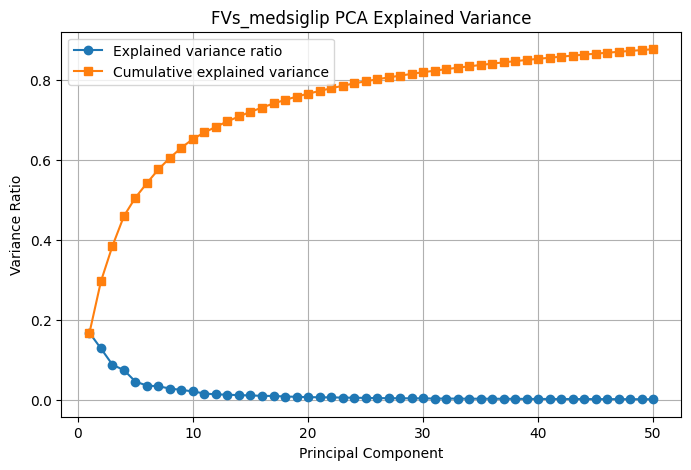

In [3]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
pca_df = meta_df.copy()

for i in range(Z.shape[1]):
    pca_df[f"PC{i+1}"] = Z[:, i]

display(pca_df.head())

,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,...,-0.539592,1.494412,0.924922,1.765142,2.088180,-1.394080,0.153395,0.507603,1.284882,0.537035
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,...,0.017861,-0.155522,0.028570,2.230282,-0.854623,-0.462724,0.408873,-0.646712,1.731559,-1.445824
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,...,-0.049515,-0.622562,2.515025,-0.245626,-1.332191,-1.494487,0.301673,-1.296637,0.876496,-2.282738
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,...,-2.594752,-0.232852,0.524813,1.952866,-0.374533,-0.442085,-0.140440,0.488700,1.135891,-2.998279
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,...,0.398691,0.144278,-2.453766,1.302608,1.538555,0.307455,-0.939416,-1.167635,-1.182510,-0.423395


### Check the distribution of eye DR level labels

In [5]:
LABEL_COL = "eye_DR_Level"

# 1. 检查缺失值
print("Total rows:", len(meta_df))
print("Missing labels:", meta_df[LABEL_COL].isna().sum())

# 2. DR label 分布
label_dist = (
    meta_df[LABEL_COL]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("DR_Level")
    .reset_index(name="count")
)

label_dist["ratio_%"] = (label_dist["count"] / label_dist["count"].sum() * 100).round(2)

display(label_dist)

Total rows: 1189
Missing labels: 0


,DR_Level,count,ratio_%
0,0.0,532,44.74
1,1.0,139,11.69
2,2.0,232,19.51
3,3.0,214,18.00
4,4.0,72,6.06


In [6]:
for threshold in [0, 1, 2, 3]:
    y = (meta_df[LABEL_COL] > threshold).astype(int)
    print(f"DR > {threshold}:")
    print(y.value_counts().sort_index())
    print()

DR > 0:
eye_DR_Level
0    532
1    657
Name: count, dtype: int64

DR > 1:
eye_DR_Level
0    671
1    518
Name: count, dtype: int64

DR > 2:
eye_DR_Level
0    903
1    286
Name: count, dtype: int64

DR > 3:
eye_DR_Level
0    1117
1      72
Name: count, dtype: int64



In [7]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

LABEL_COL = "eye_DR_Level"
N_PC = 50

rows = []

for i in range(N_PC):
    pc = f"PC{i+1}"

    tmp = pca_df[[pc, LABEL_COL]].dropna()

    if len(tmp) < 3:
        rho, p_value = np.nan, np.nan
    else:
        rho, p_value = spearmanr(tmp[pc], tmp[LABEL_COL])

    rows.append({
        "PC": pc,
        "n": len(tmp),
        "spearman_rho": rho,
        "abs_rho": abs(rho) if pd.notna(rho) else np.nan,
        "p_value": p_value
    })

spearman_df = pd.DataFrame(rows)
spearman_df = spearman_df.sort_values("abs_rho", ascending=False)

display(spearman_df.head(20))

,PC,n,spearman_rho,abs_rho,p_value
0,PC1,1189,-0.787509,0.787509,8.999141e-252
2,PC3,1189,-0.120237,0.120237,3.228357e-05
8,PC9,1189,0.116171,0.116171,5.939931e-05
4,PC5,1189,-0.091602,0.091602,1.567294e-03
7,PC8,1189,-0.059665,0.059665,3.968199e-02
5,PC6,1189,0.057047,0.057047,4.922814e-02
11,PC12,1189,0.056792,0.056792,5.024980e-02
3,PC4,1189,-0.055953,0.055953,5.375083e-02
30,PC31,1189,-0.055550,0.055550,5.550234e-02
42,PC43,1189,-0.054977,0.054977,5.807127e-02


PC1はDR重症度と強い単調関係を示した。
一方，PC3およびPC9は統計的には有意であったものの，
相関係数は約0.1であり，DR重症度との関連は弱いと考えられる。